In [1]:
from CSD_FIR_ES import ES, CSDIndividual
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import freqz

In [2]:
def target_function(w):
    return 1 if w >= 1.5 else 0

In [3]:
best, pop = ES(
    n_generations=1000,
    mu=100,
    lam=1000,
    wordlength=8,
    order=8,
    n_digits=3,
    target=target_function,
    mode="magnitude",
    plus_strategy=True
)

In [4]:
best.get_coefficients()

[[0, 0, 0, 0, -1, 0, 0, 1],
 [0, 0, 0, 1, 0, 0, -1, 0],
 [0, 0, 0, 0, 0, 1, 0, 1],
 [0, 0, -1, 0, 1, 0, 0, 1],
 [0, 0, 0, 0, 0, 0, -1, 0],
 [0, 1, 0, -1, 0, 0, 1, 0],
 [0, -1, 0, 0, 0, 0, 0, 0],
 [0, 0, 1, 0, 0, 0, 0, -1]]

In [5]:
# Frequency responses
w, H = best.get_response()
Ht = np.array([target_function(wi) for wi in w], dtype=complex)

# Magnitude / phase
mag = np.abs(H)
magt = np.abs(Ht)
ph = np.unwrap(np.angle(H))
pht = np.unwrap(np.angle(Ht))

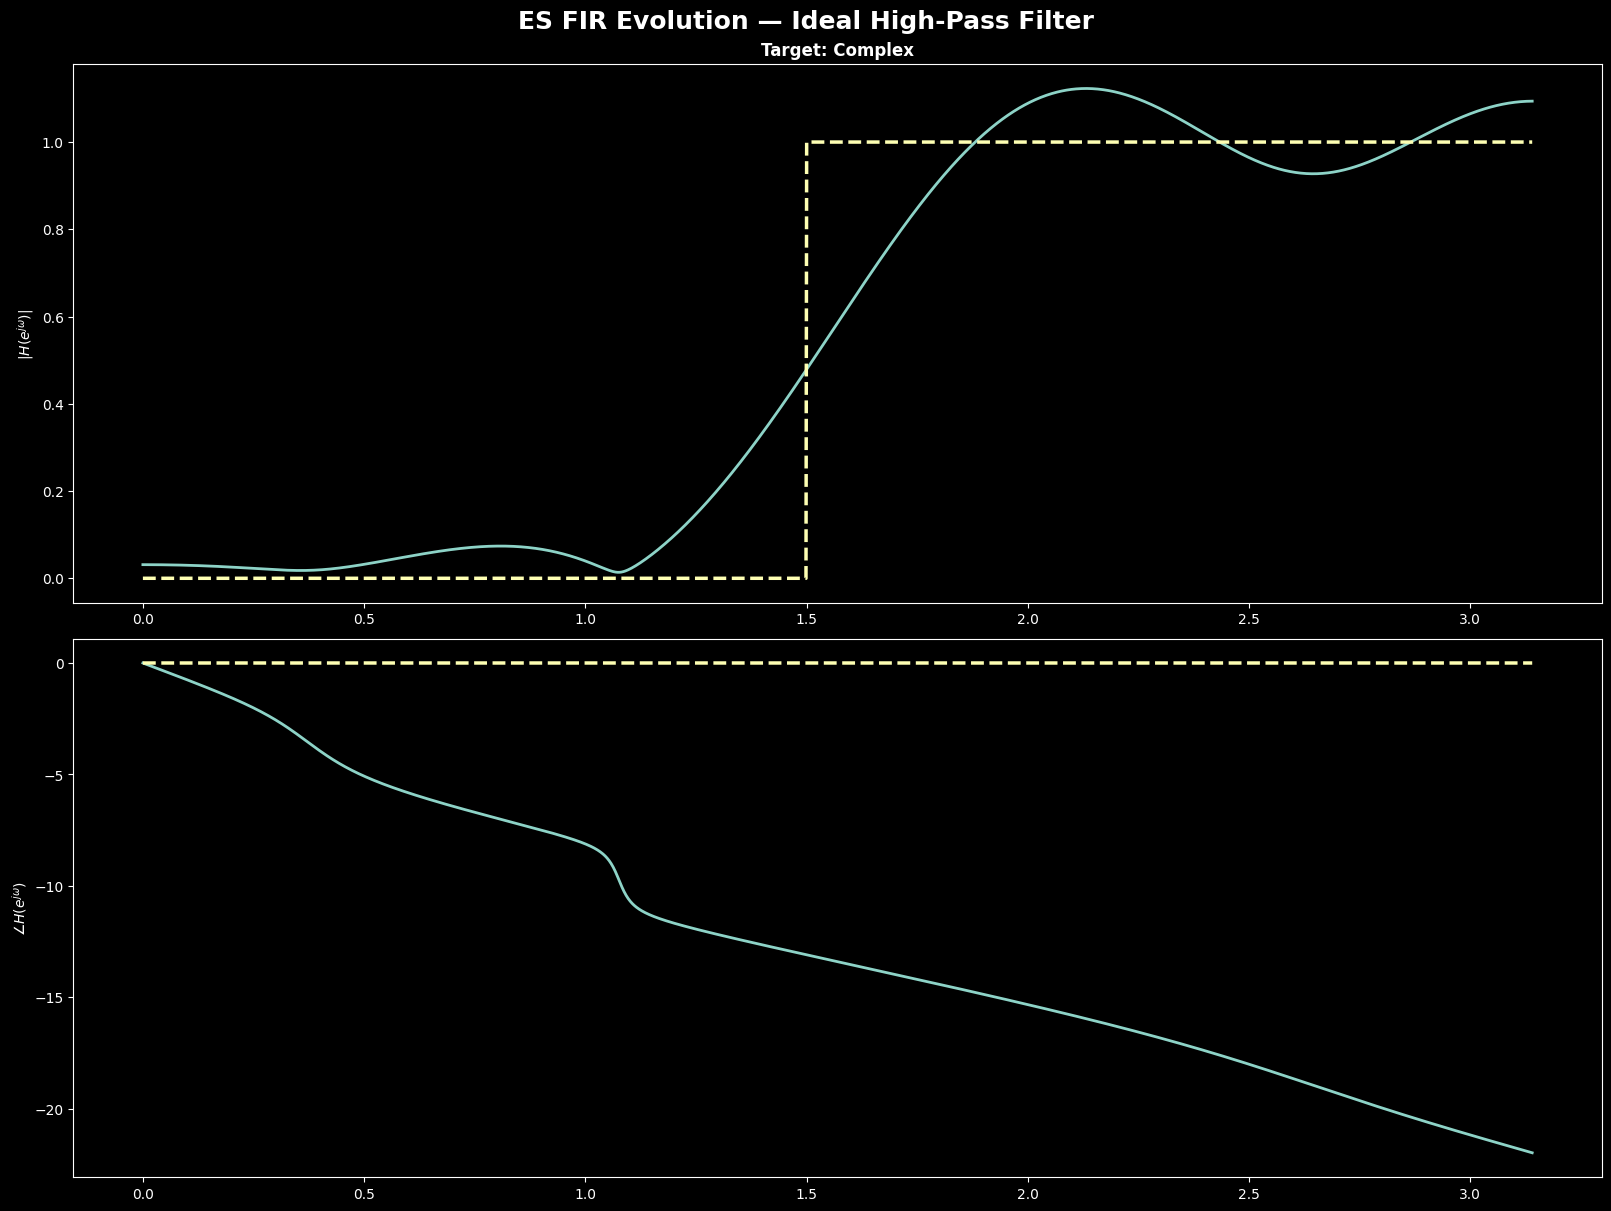

In [6]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(16, 12),
    constrained_layout=True
)

fig.suptitle(
    "ES FIR Evolution — Ideal High-Pass Filter",
    fontsize=18,
    weight="bold"
)

ax = axes[0]
ax.plot(w, mag, lw=2, label="solution")
ax.plot(w, magt, lw=2.5, ls="--", label="target")

ax.set_title(f"Target: Complex", weight="bold")
ax.set_ylabel(r"$|H(e^{j\omega})|$")

ax = axes[1]
ax.plot(w, ph, lw=2, label="solution")
ax.plot(w, pht, lw=2.5, ls="--", label="target")
ax.set_ylabel(r"$\angle H(e^{j\omega})$")

plt.show()